#### Import all the librairies 

In [1]:
import torch 
import pandas as pd 
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from torch.utils.data import Dataset
from torch.utils.data import random_split 
from torch.utils.data import DataLoader
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
from torch.optim import Adam
from tqdm import tqdm
from itertools import islice
from Early_stopping_class import EarlyStopping
from torch.optim.lr_scheduler import ReduceLROnPlateau

#### Setting the device diagnostic 

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

#### Loading the datset from French_eng.csv 

In [3]:
df = pd.read_csv('French_eng.csv')
df.head()

,topic,tense,perspective,cs_ratio,gender,age,education_level,first_language,second_language,conversation_type,cs_function,cs_type,data_generation_result,fluency_result,naturalness_result,cs_ratio_result,social_cultural_result,summary,score
0,sports,Future,First Person,70%,Female,66+,College,French,English,multi-turn,Referential,Intersentential,"[""Après la victoire du LOSC contre le Real Mad...","{'fluency_score': 9, 'errors': [], 'summary': ...","{'naturalness_score': 8.5, 'observations': {'s...","{'ratio_score': 8, 'computed_ratio': '68% Fren...","{'socio_cultural_score': 9, 'issues': 'The cod...","\n data_generation_result: [""Après la victo...",8.675
1,technology,Future,Third Person,70%,Male,26-35,High School,French,English,multi-turn,Directive,Intersentential,['La Commission européenne va établir de nouve...,"{'fluency_score': 9, 'errors': [], 'summary': ...","{'naturalness_score': 9, 'observations': {'sen...","{'ratio_score': 8, 'computed_ratio': '62% Fren...","{'socio_cultural_score': 9, 'issues': '', 'sum...",\n data_generation_result: ['La Commission ...,8.800
2,sports,Present,Third Person,70%,Male,66+,High School,French,English,single_turn,Directive,Intrasentential,"[""Il regarde le match, mais il pense que the r...","{'fluency_score': 9, 'errors': [], 'summary': ...","{'naturalness_score': 8, 'observations': {'awk...","{'ratio_score': 8, 'computed_ratio': '62% Fren...","{'socio_cultural_score': 8, 'issues': ""The cod...","\n data_generation_result: [""Il regarde le ...",8.300
3,health,Future,Third Person,70%,Male,66+,High School,French,English,single_turn,Poetic,Extra-sentential / Tag switching,"['""Selon une nouvelle recherche, le vélo est t...","{'fluency_score': 8.5, 'errors': [{'descriptio...","{'naturalness_score': 8.5, 'observations': {'s...","{'computed_ratio': '60% French : 40% English',...","{'socio_cultural_score': 8, 'issues': [""The co...","\n data_generation_result: ['""Selon une nou...",8.075
4,science,Past,First Person,70%,Male,56-65,Doctor,French,English,single_turn,Directive,Extra-sentential / Tag switching,"['En tant que médecin, j’ai lu le rapport sur ...","{'fluency_score': 9, 'errors': [], 'summary': ...","{'naturalness_score': 8.5, 'observations': {'a...","{'ratio_score': 8, 'computed_ratio': '82% Fren...","{'socio_cultural_score': 8, 'issues': ""The cod...",\n data_generation_result: ['En tant que mé...,8.425


In [4]:
df['data_generation_result'][0]

'["Après la victoire du LOSC contre le Real Madrid, je vais sûrement lire tous les articles sur le match. I\'m eager to see the expert analyses tomorrow.", \'Je pense que les supporters seront très fiers demain. I will definitely talk about it with my friends at the café.\', "Demain, je raconterai à ma petite-fille comment le LOSC a battu Ancelotti. Maybe she\'ll be inspired to follow football too!", \'Je partagerai les meilleures photos du match avec mes anciens collègues. They will love to remember these moments.\']'

In [5]:
df.columns 

Index(['topic', 'tense', 'perspective', 'cs_ratio', 'gender', 'age',
       'education_level', 'first_language', 'second_language',
       'conversation_type', 'cs_function', 'cs_type', 'data_generation_result',
       'fluency_result', 'naturalness_result', 'cs_ratio_result',
       'social_cultural_result', 'summary', 'score'],
      dtype='str')

#### Storing the "data_generation_result" column in a variable 

In [6]:
all_texts = df['data_generation_result'].dropna().tolist()

print(all_texts[:3])
print("Total samples:", len(all_texts))

['["Après la victoire du LOSC contre le Real Madrid, je vais sûrement lire tous les articles sur le match. I\'m eager to see the expert analyses tomorrow.", \'Je pense que les supporters seront très fiers demain. I will definitely talk about it with my friends at the café.\', "Demain, je raconterai à ma petite-fille comment le LOSC a battu Ancelotti. Maybe she\'ll be inspired to follow football too!", \'Je partagerai les meilleures photos du match avec mes anciens collègues. They will love to remember these moments.\']', "['La Commission européenne va établir de nouvelles règles pour l’IA à partir de l’année prochaine. These regulations will ban systems considered too dangerous, like mass surveillance or emotion recognition.', 'Les experts pensent que ces interdictions vont protéger la vie privée des citoyens. But some tech companies may argue that too many restrictions could slow innovation.', 'Il est probable que le public soutienne ces mesures, surtout après les débats récents sur l

In [7]:
lengths = [len(t.split()) for t in all_texts]

print("Max length:", max(lengths))
print("Average length:", sum(lengths)/len(lengths))

Max length: 300
Average length: 52.41350681536555


#### Load the model Qwen3-1.7B and the tokenizer from models/ folder 

In [4]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
local_model_path = "models/Qwen/Qwen3-1.7B" # Path to the downloaded model directory
device = torch.device("cuda:1")


# Load model in 4-bit to save memory (important for keyboard research)
Qwen_model = AutoModelForCausalLM.from_pretrained(
    local_model_path, 
    #device_map={ " " : 1},  # Automatically distribute layers across available devices
    torch_dtype=torch.float16,
    #load_in_4bit=True,
    local_files_only=True,
    trust_remote_code=True,
).to(device)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


OutOfMemoryError: CUDA out of memory. Tried to allocate 24.00 MiB. GPU 1 has a total capacity of 31.36 GiB of which 8.12 MiB is free. Process 451847 has 504.00 MiB memory in use. Including non-PyTorch memory, this process has 2.61 GiB memory in use. Of the allocated memory 2.10 GiB is allocated by PyTorch, and 13.86 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [8]:
# Load Qwen 1.7B tokenizer
local_model_path = "models/Qwen/Qwen3-1.7B"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tokenizer = AutoTokenizer.from_pretrained(
    local_model_path, 
    local_files_only=True,
    trust_remote_code=True)

#### Padding the tokens 

In [9]:
max_length = 400  # Set a maximum length for padding 

# All the sequences in the batch have to have the same length, so we will pad them to the maximum length in the batch.
# We add special “padding tokens” (usually 0) to make every sequence the same length.
# The encodings has two attributes: input_ids and attention_mask. The input_ids are the token ids of the input text, and the attention_mask is a binary mask that indicates which tokens are padding (0) and which are not (1).
# Example:       input_ids: [35, 102, 7, 78, 901, 0, 0]
#                attention_mask: [1, 1, 1, 1, 1, 0, 0]

encodings = tokenizer(
    all_texts,
    truncation=True,
    padding=True, 
    max_length=max_length
)
print(list(islice(encodings.keys(), 15000)))

['input_ids', 'attention_mask']


#### Create the TextDataset class 

In [10]:

class TextDataset(Dataset):
    def __init__(self, encodings):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.input_ids[idx]),  
        }

dataset = TextDataset(encodings)
dataset[0]["labels"]

tensor([  1183,  20722,  12142,   1187,   5199,  41727,   3845,  52687,     34,
         44873,    512,   8800,  24081,     11,   4759,  90407,  77605,  54655,
         77451,  25642,   3541,   9709,   1729,    512,   2432,     13,    358,
          2776,  23541,    311,   1490,    279,   6203,  27960,  16577,  10465,
           364,  29754,  72853,   1709,   3541,  15511,  77771,  24901,    282,
          4813,   2429,    466,     13,    358,    686,   8491,   3061,    911,
           432,    448,    847,   4780,    518,    279,  51950,  15670,    330,
         32003,    466,     11,   4759,  15122,    443,    465,   2143,   3784,
          7491,  37820,   2220,   4517,   3980,    512,  52687,     34,    264,
         14754,     84,  30277,    301,  41227,     13,  10696,   1340,   3278,
           387,  14606,    311,   1795,   8964,   2238,  18789,    364,  29754,
         96348,   2143,   3541,  30226,   1413,   7249,   3845,   2432,   9753,
         10846,    458,   5855,    724, 

#### Split the dataset into two splits : train and validation

In [16]:
train_size = int(0.8 * len(dataset))
validation_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)

train_dataset, validation_dataset = random_split(dataset, [train_size, validation_size], generator=generator)

#### Creating dataloaders with batchsize 8 to avoid OOM

In [17]:

BATCH_SIZE = 8

train_dataloader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True
    )

validation_dataloader = DataLoader(
    validation_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False
    )

batch = next(iter(train_dataloader))
print(batch['input_ids'].shape)

torch.Size([8, 400])


#### Setting the LoRA model 

In [40]:
Qwen_LoRA_model.unload()

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

In [14]:

Qwen_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=8,                     # rank (small = faster, bigger = stronger)
    lora_alpha=16,           # scaling (r*2)
    target_modules=["q_proj", "v_proj"],
    #target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],    
    #target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

Qwen_LoRA_model = get_peft_model(Qwen_model, lora_config)
Qwen_LoRA_model.print_trainable_parameters()

trainable params: 1,605,632 || all params: 2,033,345,536 || trainable%: 0.0790


#### Setting the optimizer AdamW 

In [15]:

optimizer = AdamW(Qwen_LoRA_model.parameters(), lr=1e-5, weight_decay=0.01)


# Check the device of the model
Qwen_model.device

device(type='cuda', index=1)

##### Setting the training and validation loop 

In [16]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 20 
early_stopping = EarlyStopping(patience=5, save_path="./3fr_en_adapter_best")
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
train_losses = []
val_losses = []
total_steps = len(train_dataloader) * epochs

from transformers import get_scheduler

# scheduler = get_scheduler(
##    "cosine",
#    optimizer=optimizer,
#    num_warmup_steps=100,
#    num_training_steps=total_steps
#)

for epoch in range(epochs):
    Qwen_LoRA_model.train()
    total_train_loss = 0
    bar = tqdm(train_dataloader , desc=f"Epoch {epoch+1}")
    for batch in bar:
        input_id=batch['input_ids'].to(Qwen_LoRA_model.device)
        attention_mask=batch['attention_mask'].to(Qwen_LoRA_model.device)
        label=batch['labels'].to(Qwen_LoRA_model.device)

        outputs = Qwen_LoRA_model(
            input_ids=input_id, 
            attention_mask=attention_mask, 
            labels=label
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(Qwen_LoRA_model.parameters(), max_norm=1.0)

        optimizer.step()

        optimizer.zero_grad()

        bar.set_postfix(loss=loss.item())

    train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(train_loss)
    print(f"Training Loss: {train_loss:.4f}")
    
    ## VAlidation 
    Qwen_LoRA_model.eval()
    total_val_loss = 0
    with torch.inference_mode():
        for batch in validation_dataloader:
            input_id=batch['input_ids'].to(Qwen_LoRA_model.device)
            attention_mask=batch['attention_mask'].to(Qwen_LoRA_model.device)
            label=batch['labels'].to(Qwen_LoRA_model.device)

            outputs = Qwen_LoRA_model(
                input_ids=input_id, 
                attention_mask=attention_mask, 
                labels=label
            )

            total_val_loss += outputs.loss.item()

    val_loss = total_val_loss / len(validation_dataloader)
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    scheduler.step()
    print(f"lr : {scheduler.get_last_lr()}")

    early_stopping(val_loss, Qwen_LoRA_model)
    
    if early_stopping.early_stop:
        print("Early stopping")
        break


Epoch 1: 100%|██████████| 908/908 [04:24<00:00,  3.44it/s, loss=0.509]


Training Loss: 2.9246
Validation Loss: 0.4922
lr : [9.938441702975689e-06]
✅ Val Loss Improved (inf -> 0.4922). Saving model...


Epoch 2: 100%|██████████| 908/908 [04:22<00:00,  3.47it/s, loss=0.381]


Training Loss: 0.4606
Validation Loss: 0.4349
lr : [9.755282581475769e-06]
✅ Val Loss Improved (0.4922 -> 0.4349). Saving model...


Epoch 3: 100%|██████████| 908/908 [04:23<00:00,  3.45it/s, loss=0.406]


...

Training Loss: 0.3909
Validation Loss: 0.3931
lr : [2.447174185242324e-07]
✅ Val Loss Improved (0.3932 -> 0.3931). Saving model...


Epoch 19: 100%|██████████| 908/908 [04:40<00:00,  3.24it/s, loss=0.475]


Training Loss: 0.3908
Validation Loss: 0.3931
lr : [6.155829702431172e-08]
✅ Val Loss Improved (0.3931 -> 0.3931). Saving model...


Epoch 20: 100%|██████████| 908/908 [04:37<00:00,  3.28it/s, loss=0.462]


Training Loss: 0.3907
Validation Loss: 0.3931
lr : [0.0]
⚠️ No improvement. Patience: 1/5


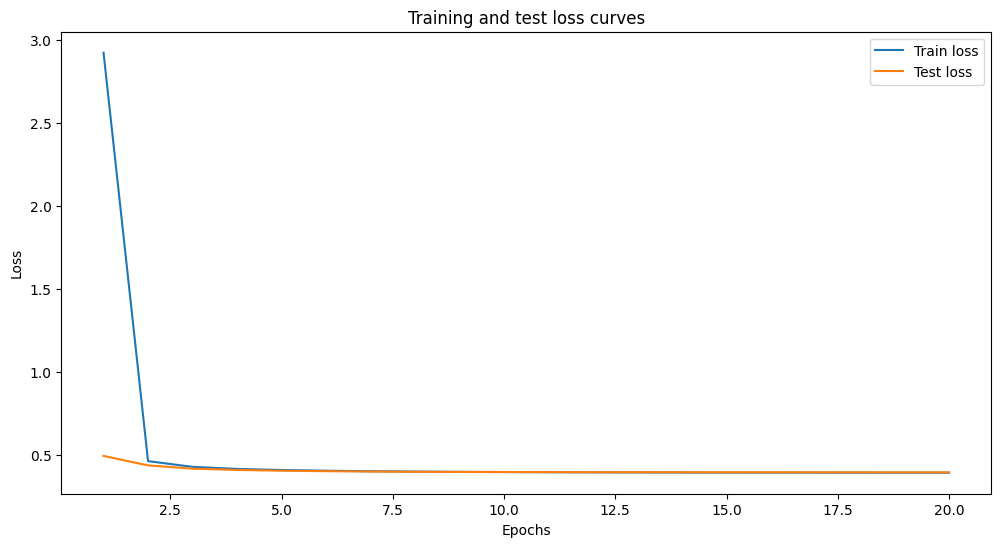

In [17]:
import matplotlib.pyplot as plt
epochs_count = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_count, train_losses, label = 'Train loss')
plt.plot(epochs_count, val_losses, label='Test loss')
plt.title('Training and test loss curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()

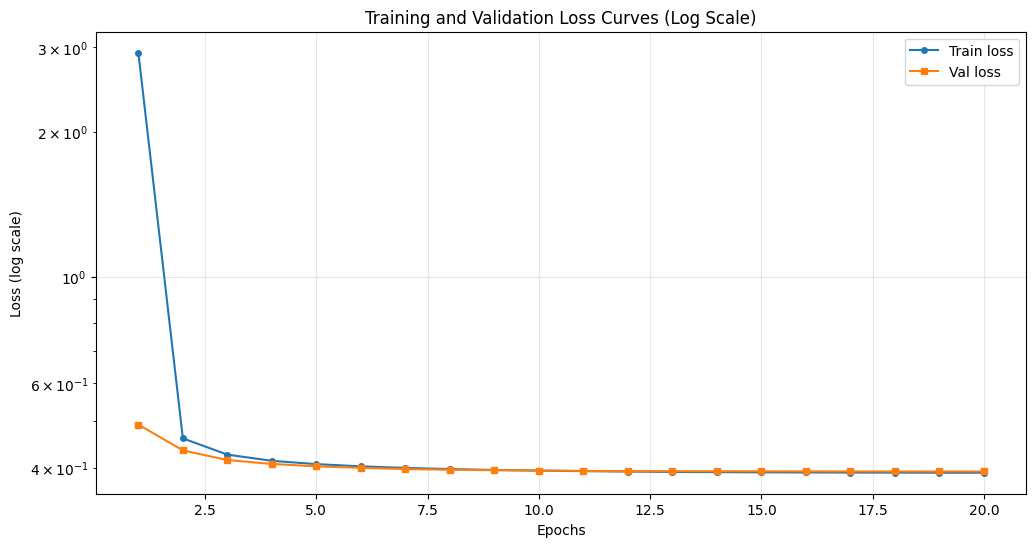

In [18]:
import matplotlib.pyplot as plt
epochs_count = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_count, train_losses, label='Train loss', marker='o', markersize=4)
plt.plot(epochs_count, val_losses, label='Val loss', marker='s', markersize=4)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.title('Training and Validation Loss Curves (Log Scale)')
plt.ylabel('Loss (log scale)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [19]:
0.3845, 0.3833, 

(0.3845, 0.3833)

In [17]:
model.unload()

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

In [13]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

tokenizer = AutoTokenizer.from_pretrained("models/Qwen/Qwen3-1.7B", trust_remote_code=True)

base_model = AutoModelForCausalLM.from_pretrained(
    "models/Qwen/Qwen3-1.7B",
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True
)

model = PeftModel.from_pretrained(base_model, "./3fr_en_adapter_best").to(torch.device("cuda:3"))
model.eval()

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-27): 28 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

In [23]:
input_text = "Je veux partir to the city"
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=10,
    do_sample=True,
    temperature=0.5
)

print(tokenizer.decode(output[0]))

Je veux partir to the city tomorrow, right? I think I'll get a
